Adapted from GD1_CWoLA_Data_prep.ipynb

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.io import fits
from astropy.table import Table
import astropy.coordinates as coord
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy import table
from tqdm import tqdm
import seaborn as sns
import pickle
from datetime import datetime, timezone, timedelta
import warnings

import torch
from torch_geometric.nn import GCNConv
from torch.utils.data import Dataset
from torch import nn
from torch.nn import Linear, LayerNorm, ReLU
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_cluster import knn_graph
from torch_geometric.nn import radius_graph
from torch_geometric.utils import to_undirected, subgraph
from torch_geometric.transforms import KNNGraph
from torch_geometric.loader import ClusterData, ClusterLoader, DataLoader
import torchvision
from torchvision.ops import sigmoid_focal_loss
from torch_geometric.nn import DeepGCNLayer, GENConv

from torchmetrics.classification import BinaryMatthewsCorrCoef

import lightning as L
from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch import seed_everything
from lightning.pytorch.callbacks import ModelCheckpoint

import wandb

from sklearn.metrics import recall_score, precision_score, f1_score, roc_curve, roc_auc_score, matthews_corrcoef
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.exceptions import UndefinedMetricWarning

from utils import count_parameters, get_mask_splits, DeeperGCN, LitDeepGCN, GaiaDataModule, GaiaDataModuleCustom
from sklearn.metrics import precision_recall_curve, average_precision_score

## Data Preparation:
Use SF labels --> crossmatch w/ Gaia ID  
Drop data points where G0, R0, Z0 undefined or create mask column

In [2]:
t = table.Table.read('/pscratch/sd/p/pratsosa/GD-1_gaia_x_decals.fits')
t

release,ra,dec,ebv,flux_g,flux_r,flux_z,flux_ivar_g,flux_ivar_r,flux_ivar_z,gdist,ruwe,pmra,pmdec,pmra_error,pmdec_error,pmra_pmdec_corr,parallax,parallax_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,source_id,pseudocolour,ecl_lat,astrometric_params_solved,nu_eff_used_in_astrometry,gmag,rmag,zmag,gmag0,rmag0,zmag0
int16,float64,float64,float32,float32,float32,float32,float32,float32,float32,float64,float32,float64,float64,float32,float32,float32,float64,float32,float32,float32,float32,int64,float32,float64,int16,float32,float32,float32,float32,float32,float32,float32
9011,120.6734119161379,53.999094470139276,0.035382394,4.408923,7.9046807,9.845077,304.4818,111.44522,108.074814,0.001313530057564124,1.0336372,0.009062617211908097,-1.1793603930567276,0.79858536,0.6578168,0.18917239,0.2424043954313359,0.8717361,20.365824,20.530807,19.771313,1032755676944123392,--,32.76199491592351,31,1.481088,20.889168,20.25529,20.016953,20.77644,20.179571,19.974636
9011,120.6681237296905,53.99711433768137,0.03528209,185.20364,270.47394,294.12344,28.254639,9.333168,5.199145,0.0012278349975922652,1.0500476,2.3023875463379637,0.4313844230847325,0.059309363,0.050162315,-0.078619055,0.32896049804789373,0.062428966,16.496391,16.80756,16.025715,1032755294691707136,--,32.75932360298912,31,1.5654057,16.830875,16.419685,16.328676,16.718466,16.344181,16.286478
9011,120.69812826945864,53.99145337726858,0.03536337,4.8044972,18.399426,43.684242,299.1685,73.95227,70.334015,0.028283750301712655,0.99584436,26.52307709604476,-50.080340559431036,0.34182414,0.2689185,0.07218132,1.4318655592640612,0.40845212,19.374294,20.289412,18.405357,1032755603929350656,--,32.75808141066702,31,1.3501854,20.79588,19.33799,18.399187,20.683212,19.262312,18.356892
9011,120.71054903117253,53.98627744998615,0.03527704,13.162658,46.14952,95.35333,277.15164,61.93007,48.357796,0.0045971584589089495,1.0668436,-6.249328669687971,-6.221427556909828,0.18977205,0.17152573,0.13573842,0.6352555996190141,0.24113286,18.425928,19.268114,17.53398,1032755402066830080,--,32.754827249898845,31,1.3640263,19.701641,18.339582,17.55166,19.589249,18.26409,17.50947
9011,120.73668283409945,53.98374970857423,0.035398282,3.496668,14.3868265,47.10974,469.63864,126.44522,70.30278,0.0009947771414561446,0.94592226,1.5290769229625945,-0.34759746800310265,0.40835255,0.3638984,0.2865606,-0.10482569667039199,0.41911656,19.512102,20.485327,18.481878,1032755363411179520,--,32.756088829253336,31,1.3248714,21.140863,19.605087,18.317223,21.028084,19.529335,18.274887
9011,120.77453923791764,53.99424074803346,0.03586958,8.426979,33.021297,146.76692,240.80241,51.094673,35.82582,0.003350640474704571,1.0126785,3.709235666671011,-5.9358413692306895,0.19500373,0.1504331,0.26813662,1.7080321482328782,0.185255,18.428513,19.885645,17.314295,1032754744935891328,--,32.77165159318021,31,1.2854763,20.18582,18.703014,17.08343,20.071539,18.626253,17.04053
9011,120.75192310899911,53.97874869265112,0.03538067,3.6434486,14.21338,58.18187,465.69574,127.22899,63.56878,0.0028925328415706354,1.0301955,-0.8371194442504939,-5.8911118886127,0.38926536,0.3252812,-0.08370603,1.4418425132362787,0.35484186,19.408625,20.739506,18.351337,1032755363411177472,1.4585134,32.753402335973135,95,--,21.096218,19.618256,18.088032,20.983496,19.542542,18.045717
9011,120.77670616555773,53.986915198479544,0.035660826,4.7970815,19.115631,62.869133,426.9613,109.4246,61.230957,0.0074087129069202095,1.0059375,-6.713559752009676,-13.289757448887894,0.29537985,0.22285053,0.23879944,0.8929180127952486,0.30218807,19.198853,20.320002,18.190075,1032754744935889792,1.4235159,32.764850927835425,95,--,20.797558,19.296528,18.003906,20.683943,19.220213,17.961256
9011,120.77687262640544,53.982581693486196,0.035543725,12.445117,34.14558,56.627754,285.77072,76.83492,64.213806,0.0015753945752849119,0.999473,-0.5807007513903247,-3.051458052089857,0.21965416,0.17001085,0.21549395,0.335417532917306,0.21925671,18.801256,19.506119,18.045055,1032754710576149376,--,32.76067154547747

In [3]:
gmag0 = np.array(t['gmag0'])
rmag0 = np.array(t['rmag0'])
zmag0 = np.array(t['zmag0'])

grz_mask = ~(np.isinf(gmag0) | np.isinf(rmag0) | np.isinf(zmag0))

In [4]:
temp_t = t[grz_mask]


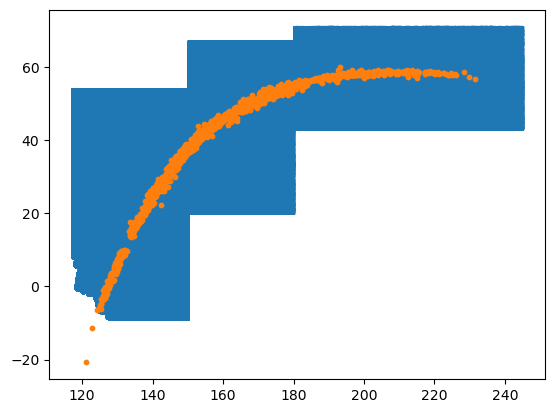

In [5]:
streamfinder = Table(fits.getdata("/pscratch/sd/p/pratsosa/general_stream_data/streamfinder_gaiadr3.fits"))

stream = streamfinder['Stream']
stream_mask = (stream == 53)
gaia_IDS = streamfinder['Gaia']
stream_IDS = np.array(gaia_IDS[stream_mask])

plt.scatter(temp_t['ra'], temp_t['dec'], s=1, alpha=0.1)
plt.scatter(streamfinder['RAdeg'][stream_mask], streamfinder['DEdeg'][stream_mask], s=10)

In [6]:
GD1_source_ids = np.array(temp_t['source_id'])
common_IDS, comm1, comm2 = np.intersect1d(GD1_source_ids, stream_IDS, return_indices=True)
stream_mask_final = np.full(len(temp_t), False, dtype=bool)
stream_mask_final[comm1] = True
print(np.sum(stream_mask_final))
temp_t['stream'] = stream_mask_final


1455


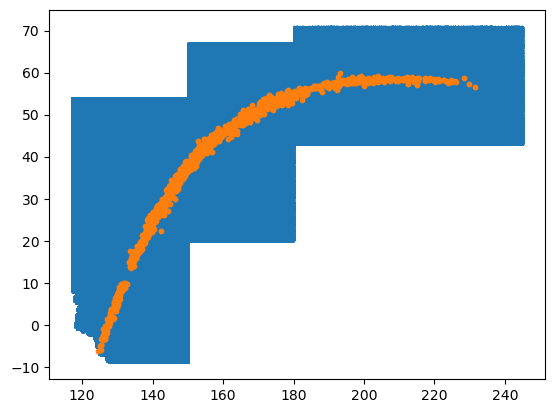

In [7]:
plt.scatter(temp_t['ra'], temp_t['dec'], s=.1)
plt.scatter(temp_t['ra'][temp_t['stream']], temp_t['dec'][temp_t['stream']], s=10)

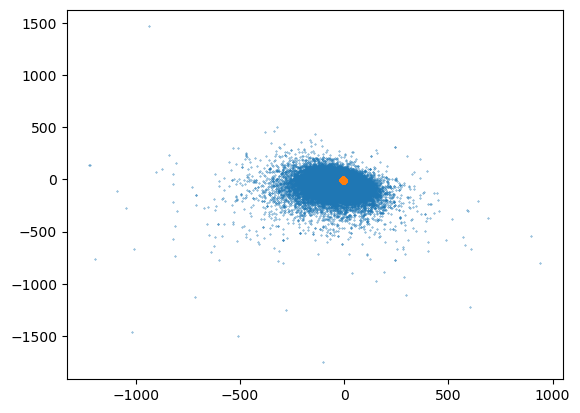

In [8]:
plt.scatter(temp_t['pmra'], temp_t['pmdec'], s=.1)
plt.scatter(temp_t['pmra'][temp_t['stream']], temp_t['pmdec'][temp_t['stream']], s=10)

In [9]:
import galstreams
mws = galstreams.MWStreams(verbose=False, implement_Off=True)
stream_track = 'GD-1-I21'

Initializing galstreams library from master_log... 


In [10]:
from adql_utils import ra_dec_to_phi1_phi2, phi1_phi2_to_ra_dec, pmra_pmdec_to_pmphi12
stream_frame = mws[stream_track].stream_frame
phi1, phi2 = ra_dec_to_phi1_phi2(stream_frame, temp_t['ra']*u.deg, temp_t['dec']*u.deg)
pm_phi1, pm_phi2 = pmra_pmdec_to_pmphi12(stream_frame, temp_t['ra']*u.deg, temp_t['dec']*u.deg,
                                        temp_t['pmra']*u.mas/u.yr, temp_t['pmdec']*u.mas/u.yr)

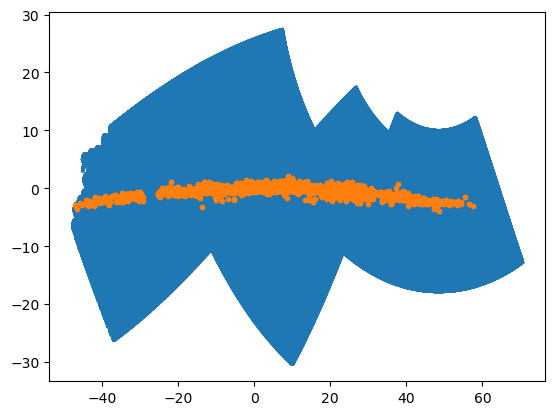

In [11]:
plt.scatter(phi1, phi2, s=.1)
plt.scatter(phi1[temp_t['stream']], phi2[temp_t['stream']], s=10)

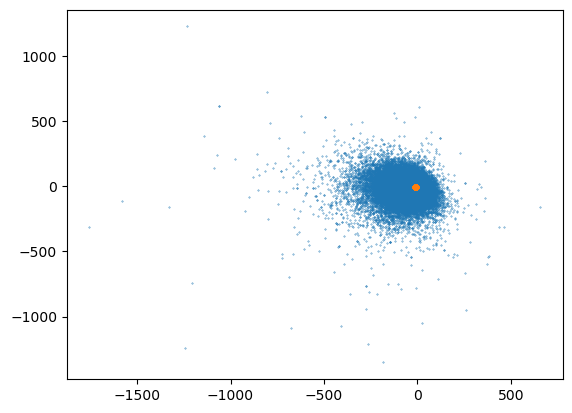

In [12]:
plt.scatter(pm_phi1, pm_phi2, s=.1)
plt.scatter(pm_phi1[temp_t['stream']], pm_phi2[temp_t['stream']], s=10)

In [13]:
temp_t['phi1'] = phi1
temp_t['phi2'] = phi2
temp_t['pm_phi1'] = pm_phi1
temp_t['pm_phi2'] = pm_phi2

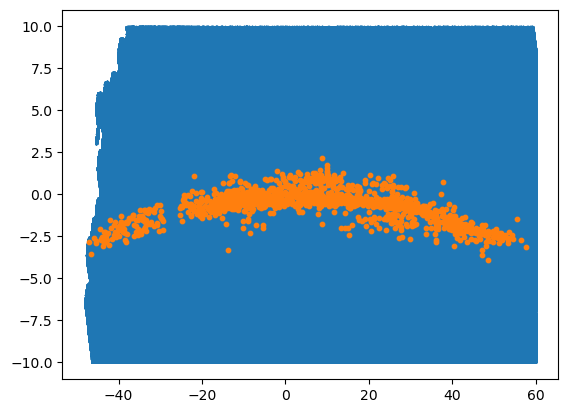

In [14]:
phi1_phi2_mask = (phi1 < 60) & (phi2 < 10) & (phi2 > -10)
plt.scatter(temp_t['phi1'][phi1_phi2_mask], temp_t['phi2'][phi1_phi2_mask], s=.1)
plt.scatter(temp_t['phi1'][temp_t['stream']], temp_t['phi2'][temp_t['stream']], s=10)

In [15]:
temp_t = temp_t[phi1_phi2_mask]

In [16]:
mws.summary.loc[stream_track, :]['distance_mid']

np.float64(7.620636575836133)

In [17]:
temp_t['stream'].sum()

np.int64(1455)

In [18]:
parallax = np.array(temp_t['parallax'])
parallax_err = np.array(temp_t['parallax_error'])

par_mask = parallax - 3 * np.abs(parallax_err) < 1 / mws.summary.loc[stream_track, :]['distance_mid']

In [19]:
temp_t['stream'][par_mask].sum()

np.int64(1446)

In [14]:
temp_t = temp_t[par_mask]
len(temp_t)

3490173

In [19]:
temp_t[0]

release,ra,dec,ebv,flux_g,flux_r,flux_z,flux_ivar_g,flux_ivar_r,flux_ivar_z,gdist,ruwe,pmra,pmdec,pmra_error,pmdec_error,pmra_pmdec_corr,parallax,parallax_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,source_id,pseudocolour,ecl_lat,astrometric_params_solved,nu_eff_used_in_astrometry,gmag,rmag,zmag,gmag0,rmag0,zmag0,grz_mask,temp_ra,stream,phi1,phi2,pm_phi1,pm_phi2
int16,float64,float64,float32,float32,float32,float32,float32,float32,float32,float64,float32,float64,float64,float32,float32,float32,float64,float32,float32,float32,float32,int64,float32,float64,int16,float32,float32,float32,float32,float32,float32,float32,bool,float64,bool,float64,float64,float64,float64
9010,344.49893007771675,-15.24974620948491,0.034556102,3.9799256,6.907926,8.427875,227.0859,71.55663,25.75503,0.0056684899156229955,1.0441324,8.436916673817866,-1.6789805574938064,1.2456206,0.82565504,-0.067294955,1.1055063353380765,1.1399089,20.536654,21.176903,19.897436,2410583242790383104,1.4695103,-7.975953300508971,95,--,21.000313,20.40163,20.185705,20.890217,20.32768,20.144377,True,344.49893007771675,False,37.25829648908978,-11.615042472011494,1.562169701449888,8.459324115865293


In [20]:
color = temp_t['phot_bp_mean_mag'] - temp_t['phot_rp_mean_mag']
color_mask = (color > 0.0) & (color < 1.0)
g_mask = temp_t['phot_g_mean_mag'] < 20.2
full_mask = color_mask & g_mask
temp_t['stream'][full_mask].sum(), len(temp_t[full_mask])

(np.int64(1430), 1802614)

In [21]:
temp_t = temp_t[full_mask]
temp_t['stream'].sum(), len(temp_t)

(np.int64(1430), 1802614)

In [22]:
pm_phi1 = np.array(temp_t['pm_phi1'])
pm_phi2 = np.array(temp_t['pm_phi2'])
phi1 = np.array(temp_t['phi1'])
phi2 = np.array(temp_t['phi2'])
stream = np.array(temp_t['stream'])
stream_pm_phi1 = pm_phi1[stream]

In [29]:
# Going to try stream cuts in different coordinates: pmra*cos(dec) and parallax

parallax = np.array(temp_t['parallax'])
dec = np.array(temp_t['dec'])
pmra = np.array(temp_t['pmra'])
pmra_cosdec = pmra * np.cos(np.radians(dec))
stream = np.array(temp_t['stream'])

stream_parallax = parallax[stream]
stream_pmra_cosdec = pmra_cosdec[stream]

par_med, par_std = np.median(parallax[stream]), np.std(parallax[stream])
par_lower_perc = np.percentile(stream_parallax, 5)
par_upper_perc = np.percentile(stream_parallax, 95)
par_lower_bound = par_med - 5 * par_std
par_upper_bound = par_med + 5 * par_std

par_regions = [[par_lower_perc, par_upper_perc], [par_lower_bound, par_upper_bound]]


pmra_med, pmra_std = np.median(pmra_cosdec[stream]), np.std(pmra_cosdec[stream])
pmra_lower_perc = np.percentile(stream_pmra_cosdec, 0)
pmra_upper_perc = np.percentile(stream_pmra_cosdec, 100)
pmra_lower_bound = pmra_med - 5 * pmra_std
pmra_upper_bound = pmra_med + 5 * pmra_std
pmra_regions = [[pmra_lower_perc, pmra_upper_perc], [pmra_lower_bound, pmra_upper_bound]]

par_signal_region = (parallax > par_regions[0][0]) & (parallax < par_regions[0][1])
par_sideband_region = (parallax > par_regions[1][0]) & (parallax < par_regions[1][1]) & ~par_signal_region

pmra_signal_region = (pmra_cosdec > pmra_regions[0][0]) & (pmra_cosdec < pmra_regions[0][1])
pmra_sideband_region = (pmra_cosdec > pmra_regions[1][0]) & (pmra_cosdec < pmra_regions[1][1]) & ~pmra_signal_region

par_stream_prop_signal = np.sum(par_signal_region[stream]) / (np.sum(par_signal_region[stream]) + np.sum(par_sideband_region[~stream]))
print(f'The proportion of stream stars in the parallax signal region is : {par_stream_prop_signal * 100}%')
par_stream_prop_sideband = np.sum(par_sideband_region[stream]) / (np.sum(par_signal_region[~stream]) + np.sum(par_sideband_region[~stream]))
print(f'The proportion of stream stars in the parallax sideband region is : {par_stream_prop_sideband * 100}%')

pmra_stream_prop_signal = np.sum(pmra_signal_region[stream]) / (np.sum(pmra_signal_region[stream]) + np.sum(pmra_sideband_region[~stream]))
print(f'The proportion of stream stars in the pmra*cos(dec) signal region is : {pmra_stream_prop_signal * 100}%')
pmra_stream_prop_sideband = np.sum(pmra_sideband_region[stream]) / (np.sum(pmra_signal_region[~stream]) + np.sum(pmra_sideband_region[~stream]))
print(f'The proportion of stream stars in the pmra*cos(dec) sideband region is : {pmra_stream_prop_sideband * 100}%')



The proportion of stream stars in the parallax signal region is : 0.010623026126902095%
The proportion of stream stars in the parallax sideband region is : 0.0005172507433324224%
The proportion of stream stars in the pmra*cos(dec) signal region is : 0.06720430107526883%
The proportion of stream stars in the pmra*cos(dec) sideband region is : 0.000516219620475335%


In [23]:
pm_p1_med, pm_p1_std= np.median(stream_pm_phi1), np.std(stream_pm_phi1)


#regions = [[pm_p1_med - 1*pm_p1_std, pm_p1_med + 1*pm_p1_std] , [pm_p1_med - 3*pm_p1_std, pm_p1_med + 3*pm_p1_std]]
# Define regions using 5 and 95 percentiles
lower_perc = np.percentile(stream_pm_phi1, 5)
upper_perc = np.percentile(stream_pm_phi1, 95)
# lower_perc = pm_p1_med - 1*pm_p1_std
# upper_perc = pm_p1_med + 1*pm_p1_std
lower_bound = pm_p1_med - 3*pm_p1_std
upper_bound = pm_p1_med + 3*pm_p1_std

regions = [[lower_perc, upper_perc], [lower_bound, upper_bound]]

sig_low, sig_high = regions[0]
side_low, side_high = regions[1]
print(f"sig_low: {sig_low}, sig_high: {sig_high}, side_low: {side_low}, side_high: {side_high}")

signal_region = (pm_phi1 > sig_low) & (pm_phi1 < sig_high)
sideband_region = (pm_phi1 > side_low) & (pm_phi1 < side_high) & ~signal_region

sig_low: -13.683773052975784, sig_high: -8.094313284435101, side_low: -18.057975833136954, side_high: -6.718996288271626


In [24]:
stream_prop_signal = np.sum(signal_region[stream]) / (np.sum(signal_region[stream]) + np.sum(signal_region[~stream]))
print(f'The proportion of stream stars in the signal region is : {stream_prop_signal * 100}%')

The proportion of stream stars in the signal region is : 0.7492687928965123%


In [25]:
stream_prop_side = np.sum(sideband_region[stream]) / (np.sum(sideband_region[stream]) + np.sum(sideband_region[~stream]))
print(f'The proportion of stream stars in the sideband region is : {stream_prop_side * 100}%')

The proportion of stream stars in the sideband region is : 0.090856041188072%


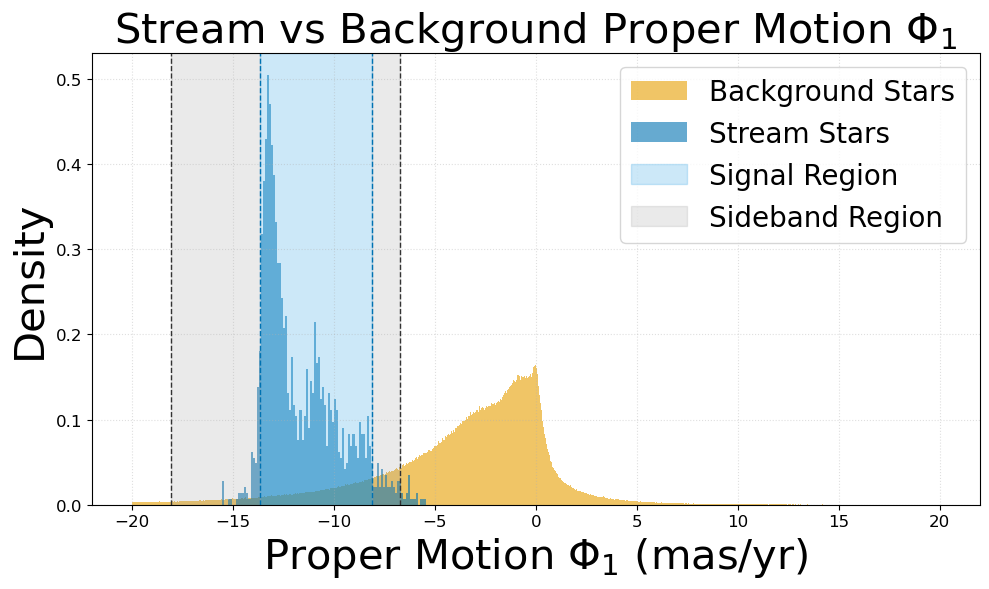

In [26]:
# Colorblind-safe colors
stream_color = '#0072B2'     # Blue
background_color = '#E69F00' # Orange
signal_shade = '#56B4E9'     # Light Blue
sideband_shade = '#999999'   # Grey
signal_line = '#0072B2'
sideband_line = '#333333'

plt.figure(figsize=(10, 6))

# Plot histograms
plt.hist(pm_phi1, density=True, bins=1000, range=(-20, 20), alpha=0.6, color=background_color, label='Background Stars')
plt.hist(stream_pm_phi1, density=True, bins=100, alpha=0.6, color=stream_color, label='Stream Stars')

# Highlight signal region (light blue)
plt.axvspan(sig_low, sig_high, color=signal_shade, alpha=0.3, label='Signal Region')

# Highlight sideband regions (light grey)
if side_low < sig_low:
    plt.axvspan(side_low, sig_low, color=sideband_shade, alpha=0.2, label='Sideband Region')
if sig_high < side_high:
    plt.axvspan(sig_high, side_high, color=sideband_shade, alpha=0.2)

# Region boundaries
plt.axvline(sig_low, color=signal_line, linestyle='--', linewidth=1)
plt.axvline(sig_high, color=signal_line, linestyle='--', linewidth=1)
plt.axvline(side_low, color=sideband_line, linestyle='--', linewidth=1)
plt.axvline(side_high, color=sideband_line, linestyle='--', linewidth=1)

# Labels and styling
plt.xlabel(r'Proper Motion $\Phi_1$ (mas/yr)', fontsize=30)
plt.ylabel('Density', fontsize=30)
plt.title(r'Stream vs Background Proper Motion $\Phi_1$', fontsize=30)
plt.tick_params(axis='both', labelsize=12)
plt.legend(fontsize=20)
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
# plt.savefig('Stream vs Background PM Phi1.png', dpi=600)
plt.show()


In [27]:
roi = sideband_region | signal_region
# signal_region = signal_region[roi]
# sideband_region = sideband_region[roi]   
np.sum(roi)

np.int64(307013)

In [29]:
temp_t['roi'] = roi
temp_t['signal_region'] = signal_region
temp_t['sideband_region'] = sideband_region

In [30]:
(temp_t['stream'].sum())

np.int64(1430)

In [31]:
temp_t = table.unique(temp_t, keys='source_id', keep='first')

In [32]:
df = temp_t.to_pandas()

ra_actual = np.array(df['ra'])
dec_actual = np.array(df['dec'])

ra = np.array(df['phi1']).astype('float64')
dec = np.array(df['phi2'])

pm_ra = np.array(df['pm_phi1']).astype('float64')
pm_dec = np.array(df['pm_phi2'])

pm_ra_error = np.array(df['pmra_error']).astype('float64')
pm_dec_error = np.array(df['pmdec_error']).astype('float64')

gmag  = np.array(df['phot_g_mean_mag'])
color = np.array(df['phot_bp_mean_mag']) - np.array(df['phot_rp_mean_mag'])
parallax = np.array(df['parallax'])
parallax_error = np.array(df['parallax_error'])

gmag0, rmag0, zmag0 = np.array(df['gmag0']), np.array(df['rmag0']), np.array(df['zmag0'])

In [33]:
full_mask = ~(np.isnan(ra) | np.isnan(dec) | np.isnan(pm_ra) | np.isnan(pm_dec) | np.isnan(gmag) | np.isnan(color) 
| np.isnan(parallax) | np.isnan(parallax_error) | np.isnan(gmag0)| np.isnan(rmag0) | np.isnan(zmag0) 
| np.isnan(pm_ra_error) | np.isnan(pm_dec_error) | np.isnan(ra_actual) | np.isnan(dec_actual) )
temp_t = temp_t[full_mask]

In [34]:
# temp_t.write('/pscratch/sd/p/pratsosa/GD-1_gaia_x_decals_stream_prep.fits', overwrite=True)